# Notebook - Find best Drug compound for `Bacillus Anthracis` bacteria. This bacteria is responsible for anthrax disease.

Data source: `PubChem + ChEMBL`

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [59]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [14]:
import csv
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from joblib import load
from PIL import Image
import pickle
import gc
from joblib import Parallel, delayed
from copy import deepcopy
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors


sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [15]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [16]:
target_organism = "BacillusAnthracis"

In [21]:
dataDir = "/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData"
modelBuildingDataDir = os.path.join(dataDir, "modelBuildingData/")
resultsDir = os.path.join(dataDir, "Results")
DORANETmoleculesDataDir = os.path.join(dataDir, "DORAnet_molecules/")

saveDir = os.path.join(resultsDir, f"{target_organism}_bestMACAW_allDB")
ARTresultsDir = f"/users/sghosh6/DTRA_project/MACAW/DTRA_ART/ART_CommandLine/{target_organism}_allDB"

os.makedirs(saveDir, exist_ok=True)

In [22]:
allBacteriaData_chEMBL = pd.read_csv(modelBuildingDataDir + 'allBacteriaData_chEMBL_uM.csv')
allBacteriaData_chEMBL

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM,pPotency,is_convertible_to_uM,potency_family,pPotencyMid
0,1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,C17H18FN3O3,MYSWGUAQZAJSOK-UHFFFAOYSA-N,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,331.35,Small molecule,0.25,ug.mL-1,...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,5.623413e+05,0.250000,True,MIC,0.250000
1,2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,C26H21ClN2O3,KEINEPLOMWOUNE-XNTDXEJSSA-N,InChI=1S/C26H21ClN2O3/c1-31-22-13-14-23(25(16-...,444.92,Small molecule,100.00,ug.mL-1,...,1.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-94,100.000000,True,MIC,100.000000
2,3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,C40H59FN10O14,VETOBWPFYDUOPP-FFKZLMLRSA-N,InChI=1S/C40H59FN10O14/c41-21-9-19-24(51(18-1-...,922.97,Small molecule,1.50,ug.mL-1,...,3.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,3.162278e+04,1.500000,True,MIC,1.500000
3,4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,C16H12N6O5,DGJBCVGFPFQIOC-CAOOACKPSA-N,InChI=1S/C16H12N6O5/c23-16(19-17-8-11-2-1-3-13...,368.31,Small molecule,16.00,ug.mL-1,...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.000000,True,MIC,16.000000
4,5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,C18H14ClN5O4S,SJWDBKWBFHCWPA-UHFFFAOYSA-N,InChI=1S/C18H14ClN5O4S/c19-13-3-1-11(2-4-13)18...,431.86,Small molecule,16.00,ug.mL-1,...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.000000,True,MIC,16.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163417,313296,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,C12H25NS3,LGZOHACUFLJANX-UHFFFAOYSA-N,InChI=1S/C12H25NS3/c1-4-7-8-9-10-11-15-16-12(1...,279.54,Small molecule,32000.00,nM,...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,3.200000e+01,4.494850,True,MIC,4.494850
163418,313298,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,C145H210N28O21,QNANZYFCKTWPTJ-WSPVJQGRSA-N,InChI=1S/C145H210N28O21/c1-93(174)154-76-36-65...,2681.45,Small molecule,46600.00,nM,...,NaN,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.660000e+01,4.331614,True,MIC,4.331614
163419,313304,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,C16H19N3O,XVNKQYMDQJGTEQ-UHFFFAOYSA-N,"InChI=1S/C16H19N3O/c1-16(2,13-6-4-3-5-7-13)11-...",269.35,NaN,256.00,ug.mL-1,...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,1.000000e-250,256.000000,True,MIC,256.000000
163420,313309,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,C9H10N2OS2,SATLYQNFXURMCO-UXBLZVDNSA-N,InChI=1S/C9H10N2OS2/c1-14-9(13)11-10-6-7-4-2-3...,226.33,Small molecule,4000.00,nM,...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.000000e+00,5.397940,True,IC/EC,5.397940


### Filter columns

In [23]:
allBacteriaData_chEMBL = allBacteriaData_chEMBL.rename(
    columns={'Virus': 'Bacteria'})
allBacteriaData_chEMBL = allBacteriaData_chEMBL.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Bacteria"]
)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,Bacteria
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilisData_chEMBL_combined.csv
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilisData_chEMBL_combined.csv
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilisData_chEMBL_combined.csv
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,3.200000e+01,4.494850,Yersinia_pestisData_chEMBL_combined.csv
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.660000e+01,4.331614,Yersinia_pestisData_chEMBL_combined.csv
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000000e-250,256.000000,Yersinia_pestisData_chEMBL_combined.csv
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000000e+00,5.397940,Yersinia_pestisData_chEMBL_combined.csv


### Remove the trailing 'Data_chEMBL_combined.csv' from each entry in the 'Bacteria' column

In [24]:
allBacteriaData_chEMBL['Bacteria'] = allBacteriaData_chEMBL['Bacteria'].str.replace('Data_chEMBL_combined.csv', '', regex=False)
allBacteriaData_chEMBL.rename(columns={'Bacteria': 'BacteriaClassifier'}, inplace=True)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,BacteriaClassifier
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilis
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilis
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilis
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilis
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilis
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,3.200000e+01,4.494850,Yersinia_pestis
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.660000e+01,4.331614,Yersinia_pestis
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000000e-250,256.000000,Yersinia_pestis
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000000e+00,5.397940,Yersinia_pestis


### Keep only data for `Bacillus_anthracis` bacteria

In [25]:
BacillusAnthracisData_chEMBL = allBacteriaData_chEMBL[allBacteriaData_chEMBL['BacteriaClassifier'] == 'Bacillus_anthracis']
BacillusAnthracisData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,BacteriaClassifier
162379,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,7.585776e+05,0.12,Bacillus_anthracis
162380,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162381,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162382,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162383,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,1.000000e+04,2.00,Bacillus_anthracis
...,...,...,...,...,...
163230,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,1.000000e+01,5.00,Bacillus_anthracis
163231,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],1.000000e-44,50.00,Bacillus_anthracis
163232,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,1.000000e-194,200.00,Bacillus_anthracis
163233,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,1.584893e-02,7.80,Bacillus_anthracis


### Remove `Basidalin` from training set

In [26]:
#Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Basidalin_SMILES='C1=C(/C(=C\C=O)/OC1=O)N'

# Canonicalize the Remdesivir SMILES
remMol = Chem.MolFromSmiles(Basidalin_SMILES)
remCan = Chem.MolToSmiles(remMol, canonical=True)

# Canonicalize all SMILES in your dataframe
BacillusAnthracisData_chEMBL["canonical_smiles"] = (
    BacillusAnthracisData_chEMBL["smiles"]
    .apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
          if Chem.MolFromSmiles(s) else None)
)

# Remove rows matching Remdesivir
mask = BacillusAnthracisData_chEMBL["canonical_smiles"] != remCan
BacillusAnthracisData_chEMBL_clean = BacillusAnthracisData_chEMBL[mask].copy()

print("Original shape of data frame:", len(BacillusAnthracisData_chEMBL))
print("After removing Basidalin:", len(BacillusAnthracisData_chEMBL_clean))
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL_clean.copy()

Original shape of data frame: 856
After removing Basidalin: 856


### Rename columns

In [27]:
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    #"pPotencyMid" : "pPotency",
})
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL.filter(
    items=["compound_id", "Smiles", "pPotency", "BacteriaClassifier"]
)
BacillusAnthracisData_chEMBL.head()

,compound_id,Smiles,pPotency,BacteriaClassifier
162379,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.12,Bacillus_anthracis
162380,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162381,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162382,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162383,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.00,Bacillus_anthracis


### Add `ID` column to left; keep only these columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `BacteriaClassifier`

In [28]:
BacillusAnthracisData_chEMBL.insert(0, 'ID', range(1, len(BacillusAnthracisData_chEMBL) + 1))
BacillusAnthracisData_chEMBL.head()

,ID,compound_id,Smiles,pPotency,BacteriaClassifier
162379,1,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.12,Bacillus_anthracis
162380,2,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162381,3,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162382,4,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162383,5,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.00,Bacillus_anthracis


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [29]:
print("Original shape:", BacillusAnthracisData_chEMBL.shape)

BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL[BacillusAnthracisData_chEMBL['pPotency'].notna() 
    & (BacillusAnthracisData_chEMBL['pPotency'] > 0) & (BacillusAnthracisData_chEMBL['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", BacillusAnthracisData_chEMBL.shape)

Original shape: (856, 5)
Shape after cleaning 'pPotency' value: (672, 5)


In [30]:
duplicates = BacillusAnthracisData_chEMBL.duplicated(subset=['Smiles'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 274


In [31]:
BacillusAnthracisData_chEMBL.to_csv(os.path.join(saveDir, f"{target_organism}Data_chEMBL_MLready.csv"),index=False)

### Read `Pubchem` bioassay data for Bacillus Anthrasis Bacteria

In [32]:
BacillusAnthracisData_Pubchem = pd.read_csv(os.path.join(modelBuildingDataDir, "allBacteria_Pubchem.csv"))
# Keep only data for Bacillus_anthracis Bacteria
BacillusAnthracisData_Pubchem = BacillusAnthracisData_Pubchem[BacillusAnthracisData_Pubchem['Bacteria'] == 'Bacillus_anthracis']
BacillusAnthracisData_Pubchem

,Bacteria,compound_id,Smiles,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996
...,...,...,...,...
3477,Bacillus_anthracis,7117403,O=C(C(=O)N1CC=C(c2ccccc2)CC1)c1c[nH]c2ccccc12,4.920819
3478,Bacillus_anthracis,54595320,N#Cc1ccc(Oc2ccccc2O)c(F)c1,4.958607
3479,Bacillus_anthracis,43458374,CN(Cc1ccccc1N)C(=O)c1cc2ccccc2o1,4.346787
3480,Bacillus_anthracis,4117778,O=C(COc1ccccc1)NCCSc1c[nH]c2ccccc12,5.468521


In [33]:
# Rename columns
BacillusAnthracisData_Pubchem = BacillusAnthracisData_Pubchem.rename(
    columns={'Bacteria': 'BacteriaClassifier'})
BacillusAnthracisData_Pubchem

,BacteriaClassifier,compound_id,Smiles,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996
...,...,...,...,...
3477,Bacillus_anthracis,7117403,O=C(C(=O)N1CC=C(c2ccccc2)CC1)c1c[nH]c2ccccc12,4.920819
3478,Bacillus_anthracis,54595320,N#Cc1ccc(Oc2ccccc2O)c(F)c1,4.958607
3479,Bacillus_anthracis,43458374,CN(Cc1ccccc1N)C(=O)c1cc2ccccc2o1,4.346787
3480,Bacillus_anthracis,4117778,O=C(COc1ccccc1)NCCSc1c[nH]c2ccccc12,5.468521


In [34]:
BacillusAnthracisData_Pubchem = BacillusAnthracisData_Pubchem[
    ['compound_id', 'Smiles', 'pPotency', 'BacteriaClassifier']]
BacillusAnthracisData_Pubchem.head()

,compound_id,Smiles,pPotency,BacteriaClassifier
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,Bacillus_anthracis
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,Bacillus_anthracis
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,Bacillus_anthracis
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,Bacillus_anthracis
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,Bacillus_anthracis


### Remove `ID` columns from left from `chEMBL` data frame

In [35]:
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL[
    ['compound_id', 'Smiles', 'pPotency', 'BacteriaClassifier']]
BacillusAnthracisData_chEMBL

,compound_id,Smiles,pPotency,BacteriaClassifier
162379,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.120000,Bacillus_anthracis
162380,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.000000,Bacillus_anthracis
162381,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.000000,Bacillus_anthracis
162382,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.000000,Bacillus_anthracis
162383,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.000000,Bacillus_anthracis
...,...,...,...,...
163227,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606,Bacillus_anthracis
163229,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276,Bacillus_anthracis
163230,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,Bacillus_anthracis
163233,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,Bacillus_anthracis


### Combine `Pubchem + chEMBL` data

In [36]:
BacillusAnthracisData_allDB = pd.concat(
    [BacillusAnthracisData_Pubchem, BacillusAnthracisData_chEMBL],
    ignore_index=True
)

BacillusAnthracisData_allDB

,compound_id,Smiles,pPotency,BacteriaClassifier
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,Bacillus_anthracis
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,Bacillus_anthracis
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,Bacillus_anthracis
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,Bacillus_anthracis
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,Bacillus_anthracis
...,...,...,...,...
4149,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606,Bacillus_anthracis
4150,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276,Bacillus_anthracis
4151,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,Bacillus_anthracis
4152,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,Bacillus_anthracis


### Canonicalize the `Smiles`

In [37]:
def canonicalize_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

BacillusAnthracisData_allDB['Smiles'] = (
    BacillusAnthracisData_allDB['Smiles']
    .astype(str)
    .apply(canonicalize_smiles)
)
BacillusAnthracisData_allDB

,compound_id,Smiles,pPotency,BacteriaClassifier
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,Bacillus_anthracis
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,Bacillus_anthracis
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,Bacillus_anthracis
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,Bacillus_anthracis
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,Bacillus_anthracis
...,...,...,...,...
4149,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606,Bacillus_anthracis
4150,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276,Bacillus_anthracis
4151,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,Bacillus_anthracis
4152,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,Bacillus_anthracis


### Remove `Basidalin` from training set

In [38]:
#Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Basidalin_SMILES='C1=C(/C(=C\C=O)/OC1=O)N'

# Canonicalize the Remdesivir SMILES
remMol = Chem.MolFromSmiles(Basidalin_SMILES)
remCan = Chem.MolToSmiles(remMol, canonical=True)

# Canonicalize all SMILES in your dataframe
BacillusAnthracisData_allDB["canonical_smiles"] = (
    BacillusAnthracisData_allDB["Smiles"]
    .apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
          if Chem.MolFromSmiles(s) else None)
)

# Remove rows matching Remdesivir
mask = BacillusAnthracisData_allDB["canonical_smiles"] != remCan
BacillusAnthracisData_allDB_clean = BacillusAnthracisData_allDB[mask].copy()

print("Original shape of data frame:", len(BacillusAnthracisData_allDB))
print("After removing Basidalin:", len(BacillusAnthracisData_allDB_clean))
BacillusAnthracisData_allDB = BacillusAnthracisData_allDB_clean.copy()

Original shape of data frame: 4154
After removing Basidalin: 4154


### Add `ID` column to left; keep only these columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `BacteriaClassifier`

In [39]:
BacillusAnthracisData_allDB.insert(0, 'ID', range(1, len(BacillusAnthracisData_allDB) + 1))
BacillusAnthracisData_allDB.head()

,ID,compound_id,Smiles,pPotency,BacteriaClassifier,canonical_smiles
0,1,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,Bacillus_anthracis,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...
1,2,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,Bacillus_anthracis,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...
2,3,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,Bacillus_anthracis,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1
3,4,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,Bacillus_anthracis,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...
4,5,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,Bacillus_anthracis,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [40]:
# Define bins and labels
bins = [0, 3, 10, 12, float('inf')]
labels = ['0-3', '3-10', '10-12', '> 12']

# Create categories
BacillusAnthracisData_allDB['pPotency_category'] = pd.cut(
    BacillusAnthracisData_allDB['pPotency'], 
    bins=bins, 
    labels=labels, 
    right=False  # right=False means 0 <= x < 3, 3 <= x < 10, etc.
)

# Count values per category
category_counts = BacillusAnthracisData_allDB['pPotency_category'].value_counts().sort_index()
print("pPotency Distribution:")
print(category_counts)
print(f"\nTotal: {category_counts.sum()}")

pPotency Distribution:
pPotency_category
0-3       813
3-10     3259
10-12       9
> 12        0
Name: count, dtype: int64

Total: 4081


In [41]:
print("Original shape:", BacillusAnthracisData_allDB.shape)

BacillusAnthracisData_allDB = BacillusAnthracisData_allDB[BacillusAnthracisData_allDB['pPotency'].notna() 
    & (BacillusAnthracisData_allDB['pPotency'] > 0) & (BacillusAnthracisData_allDB['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", BacillusAnthracisData_allDB.shape)

Original shape: (4154, 7)
Shape after cleaning 'pPotency' value: (4081, 7)


In [42]:
duplicates = BacillusAnthracisData_allDB.duplicated(subset=['Smiles'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 2434


In [43]:
BacillusAnthracisData_allDB.to_csv(os.path.join(saveDir, f"{target_organism}Data_allDB_MLready.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

## 2. Find best `MACAW` parameters to train ML Model

In [45]:
# df = BacillusAnthracisData_allDB
Y = BacillusAnthracisData_allDB.pPotency
smiles = BacillusAnthracisData_allDB.Smiles

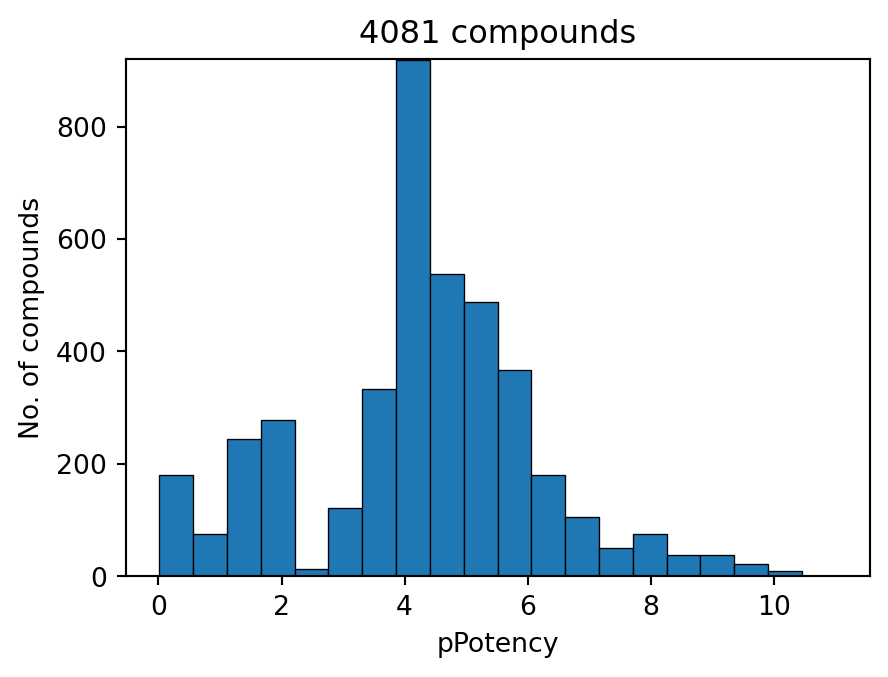

In [46]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [47]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

### 2.1 Define hyperparameters for SVR:

In [48]:
param_grid = {
    "C": [1, 10, 50, 100, 300],
    "gamma": ["scale", 0.01, 0.05, 0.1],
    "epsilon": [0.1, 0.5, 1, 3],
    "kernel": ["rbf"]
}

### 2.2 Find best `MACAW` parameters

In [49]:
nComponentsList = [30, 45, 60, 90]      # set your limits
nLandmarksList  = [500, 750, 1000, 1250, 1500, 2000, 3000] # set your limits

In [48]:
def processFold(
    foldId, trainIndex, testIndex,
    smiles, Y, baseMacaw, param_grid, numFolds
):
    print(f"Fold {foldId}/{numFolds}")

    smiTrain = smiles.iloc[trainIndex]
    smiTest  = smiles.iloc[testIndex]
    yTrain   = Y.iloc[trainIndex].values
    yTest    = Y.iloc[testIndex].values

    macawFold = deepcopy(baseMacaw)
    macawFold.fit(smiTrain, yTrain)

    XTrain = macawFold.transform(smiTrain)
    XTest  = macawFold.transform(smiTest)

    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(XTrain, yTrain)

    yPredTrain = grid.predict(XTrain)
    yPredTest  = grid.predict(XTest)

    best_params = grid.best_params_
    # Keep the keys in the same order as param_grid
    best_params_ordered = {k: best_params.get(k) for k in param_grid.keys()}
    print("Best SVR parameters:", best_params_ordered)

    return {
        "yObsTrain": yTrain,
        "yPredTrain": yPredTrain,
        "yObsTest": yTest,
        "yPredTest": yPredTest,
        "bestSvrParams": best_params,
        "bestParamsOrdered": best_params_ordered,
    }


# Collect results
macawResultsList = []

# Iterate over MACAW hyperparameters
for nComponents in nComponentsList:
    for nLandmarks in nLandmarksList:

        baseMacaw = MACAW(
            type_fp="atompairs",
            metric="sokal",
            n_components=nComponents,
            n_landmarks=nLandmarks,
            random_state=42
        )

        foldResults = Parallel(n_jobs=16, verbose=10)(
            delayed(processFold)(
                foldId=i + 1,
                trainIndex=trainIdx,
                testIndex=testIdx,
                smiles=smiles,
                Y=Y,
                baseMacaw=baseMacaw,
                param_grid=param_grid,
                numFolds=num_of_partitions,
            )
            for i, (trainIdx, testIdx) in enumerate(kf.split(smiles))
        )

        yObsTrainAll  = np.concatenate([r["yObsTrain"] for r in foldResults])
        yPredTrainAll = np.concatenate([r["yPredTrain"] for r in foldResults])
        yObsTestAll   = np.concatenate([r["yObsTest"] for r in foldResults])
        yPredTestAll  = np.concatenate([r["yPredTest"] for r in foldResults])

        trainR2 = r2_score(yObsTrainAll, yPredTrainAll)
        testR2  = r2_score(yObsTestAll, yPredTestAll)
        gapR2   = trainR2 - testR2  # simple overfit indicator

        macawResultsList.append({
            "n_components": nComponents,
            "n_landmarks": nLandmarks,
            "trainR2": trainR2,
            "testR2": testR2,
            "gapR2": gapR2,
            "testMAE": mean_absolute_error(yObsTestAll, yPredTestAll),
            "testRMSE": np.sqrt(mean_squared_error(yObsTestAll, yPredTestAll)),
        })

        print(
            f"MACAW(n_components={nComponents}, n_landmarks={nLandmarks}) "
            f"=> Test R²={testR2:.3f}, Train R²={trainR2:.3f}, Gap={gapR2:.3f}"
        )

# Build results DataFrame
macawResultsDF = pd.DataFrame(macawResultsList)

# ---- Choose best generalization: max test R² ----
bestGeneralizationRow = macawResultsDF.sort_values("testR2", ascending=False).iloc[0]

best_n_components = int(bestGeneralizationRow["n_components"])
best_n_landmarks  = int(bestGeneralizationRow["n_landmarks"])

print("\nBest MACAW by generalization (highest CV Test R²):")
print("mcw = MACAW(")
print("    type_fp='atompairs', ")
print("    metric='sokal', ")
print(f"    n_components={best_n_components}, ")
print(f"    n_landmarks={best_n_landmarks}, ")
print("    random_state=42")
print(")")

MACAW(n_components=30, n_landmarks=500) => Test R²=0.479, Train R²=0.493, Gap=0.014
MACAW(n_components=30, n_landmarks=750) => Test R²=0.455, Train R²=0.467, Gap=0.012
MACAW(n_components=30, n_landmarks=1000) => Test R²=0.442, Train R²=0.452, Gap=0.010
MACAW(n_components=30, n_landmarks=1250) => Test R²=0.443, Train R²=0.451, Gap=0.008
MACAW(n_components=30, n_landmarks=1500) => Test R²=0.436, Train R²=0.443, Gap=0.007
MACAW(n_components=30, n_landmarks=2000) => Test R²=0.446, Train R²=0.448, Gap=0.002
MACAW(n_components=30, n_landmarks=3000) => Test R²=0.439, Train R²=0.446, Gap=0.007
MACAW(n_components=45, n_landmarks=500) => Test R²=0.465, Train R²=0.485, Gap=0.020
MACAW(n_components=45, n_landmarks=750) => Test R²=0.460, Train R²=0.476, Gap=0.017
MACAW(n_components=45, n_landmarks=1000) => Test R²=0.477, Train R²=0.494, Gap=0.017
MACAW(n_components=45, n_landmarks=1250) => Test R²=0.467, Train R²=0.487, Gap=0.020
MACAW(n_components=45, n_landmarks=1500) => Test R²=0.470, Train R²=0

### Run the ML model with best MACAW parameters

In [50]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=90, 
    n_landmarks=500, 
    random_state=42
)

In [51]:
param_grid = {
    'C': [50], 
    'epsilon': [0.5],
    'gamma': [0.01],
    'kernel': ['rbf']
}

After cleaning NaN values, reset the indices

In [52]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True) 


print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 4081 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [53]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.88
  RMSE: 1.31
  R²:   0.53
Test Set:
  MAE:  0.90
  RMSE: 1.34
  R²:   0.51

Best params (sample): [{'C': 50, 'epsilon': 0.5, 'gamma': 0.01, 'kernel': 'rbf'}, {'C': 50, 'epsilon': 0.5, 'gamma': 0.01, 'kernel': 'rbf'}, {'C': 50, 'epsilon': 0.5, 'gamma': 0.01, 'kernel': 'rbf'}]
CPU times: user 865 ms, sys: 483 ms, total: 1.35 s
Wall time: 23.9 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracis_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracis_CV_TrTs.png


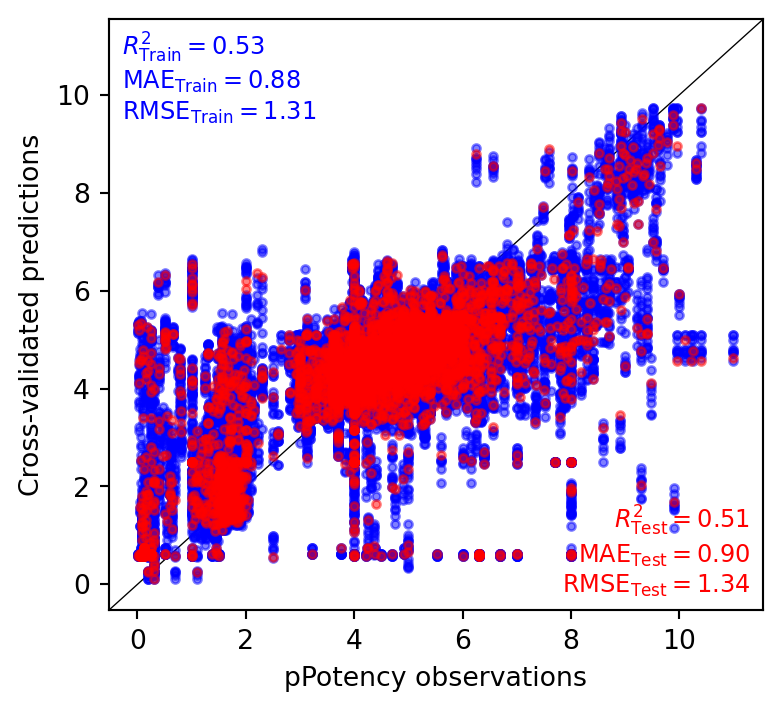

In [54]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + '/BacillusAnthracis_CV_TrTs.svg',
            save_formats=['svg', 'png'])

### Create MACAW embeedings to run `ART`

In [55]:
# Fit MACAW on SMILES and pPotency
mcw.fit(BacillusAnthracisData_allDB['Smiles'], BacillusAnthracisData_allDB['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(saveDir, f"{target_organism}Data_allDB_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracisData_allDB['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracisData_allDB.index)


BacillusAnthracisData_allDB_wMACAW = pd.concat([BacillusAnthracisData_allDB, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracisData_allDB.shape}")
print(f"New dataframe shape: {BacillusAnthracisData_allDB_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracisData_allDB_wMACAW

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracisData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (4081, 90)

Original dataframe shape: (4081, 7)
New dataframe shape: (4081, 97)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58',

,ID,compound_id,Smiles,pPotency,BacteriaClassifier,canonical_smiles,pPotency_category,MACAW_1,MACAW_2,MACAW_3,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,1,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,Bacillus_anthracis,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,3-10,-0.021547,-0.087225,0.021404,...,-0.010272,0.012309,-0.017448,-0.000035,-0.014912,-0.026106,0.039952,-0.011383,-0.034568,0.032935
1,2,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,Bacillus_anthracis,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,3-10,0.066620,-0.243946,0.022669,...,-0.011253,-0.002448,-0.014319,0.007077,-0.005703,-0.003603,-0.061587,0.031002,-0.030319,0.038735
2,3,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,Bacillus_anthracis,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,3-10,0.055315,-0.163706,0.092076,...,0.048354,0.053849,0.025467,-0.001511,0.048082,-0.022568,-0.070715,0.087138,0.120848,-0.035076
3,4,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,Bacillus_anthracis,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,3-10,0.066620,-0.243946,0.022669,...,-0.011253,-0.002448,-0.014319,0.007077,-0.005703,-0.003603,-0.061587,0.031002,-0.030319,0.038735
4,5,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,Bacillus_anthracis,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,3-10,0.055315,-0.163706,0.092076,...,0.048354,0.053849,0.025467,-0.001511,0.048082,-0.022568,-0.070715,0.087138,0.120848,-0.035076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4149,4150,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606,Bacillus_anthracis,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,3-10,-0.073695,-0.201158,-0.114346,...,0.044484,-0.039231,-0.030087,0.029348,0.022040,0.040301,0.016524,-0.061330,0.016051,0.039127
4150,4151,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276,Bacillus_anthracis,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,3-10,0.059926,-0.065624,-0.018792,...,0.024393,-0.018766,-0.012481,-0.070545,0.002283,0.002058,0.031113,-0.036097,0.030267,0.005757
4151,4152,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,Bacillus_anthracis,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,3-10,0.144828,0.009992,0.073558,...,0.030702,-0.005911,-0.050602,-0.036700,0.028052,-0.058443,-0.046005,-0.028516,0.036423,0.021321
4152,4153,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,Bacillus_anthracis,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,3-10,0.159965,-0.099642,0.052330,...,-0.032179,-0.024883,-0.009078,-0.004752,0.002602,-0.007436,-0.022274,0.011908,0.009133,-0.033252


In [56]:
BacillusAnthracisData_allDB_wMACAW.to_csv(os.path.join(saveDir, f"{target_organism}Data_allDB_wMACAW.csv"), index=False)

## 2. Discovery of new hits specific to all Bacteriaes

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antibioticsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

### 2.1 Create a list of data frames of all buyable antibiotic

In [81]:
EnamineAntibioticData = pd.read_csv(dataDir + "Enamine/Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntibioticData.shape}")

smiles_train = BacillusAnthracisData_allDB.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntibioticData['Canonical_SMILES'] = EnamineAntibioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntibioticData['Canonical_SMILES'].isin(canonical_train)
EnamineAntibioticData_filtered = EnamineAntibioticData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntibioticData = EnamineAntibioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntibioticData.shape}")
print(f"Removed {EnamineAntibioticData_filtered.shape[0] - EnamineAntibioticData.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib_EnamineDataset = EnamineAntibioticData.SMILES
EnamineAntibioticData['source_DataBase'] = 'Enamine_Antibiotic'
needed_cols = ['SMILES', 'source_DataBase']
EnamineAntibioticData = EnamineAntibioticData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_EnamineDataset)}")
EnamineAntibioticData.head()

Original Enamine data shape: (32000, 11)
Number of unique SMILES in training set: 1647
Filtered Enamine data shape for validation: (32000, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 32000


,SMILES,source_DataBase
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,Enamine_Antibiotic
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,Enamine_Antibiotic
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,Enamine_Antibiotic
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,Enamine_Antibiotic
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,Enamine_Antibiotic


In [82]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibioticData = pd.DataFrame(records)

print(f"Original LifeChemicals data shape: {LCAntibioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntibioticData['Canonical_SMILES'] = LCAntibioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntibioticData['Canonical_SMILES'].isin(canonical_train)
LCAntibioticData_filtered = LCAntibioticData[mask].copy()

# Remove the helper column if you don't need it
LCAntibioticData = LCAntibioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntibioticData.shape}")
print(f"Removed {LCAntibioticData_filtered.shape[0] - LCAntibioticData.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib_LCAntibioticData = LCAntibioticData.SMILES
LCAntibioticData['source_DataBase'] = 'LifeChemicals_Antibiotic'
needed_cols = ['SMILES', 'source_DataBase']
LCAntibioticData = LCAntibioticData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_LCAntibioticData)}")
LCAntibioticData.head()

Original LifeChemicals data shape: (15538, 26)
Number of unique SMILES in training set: 1647
Filtered LifeChemicals data shape for validation: (15521, 26)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 15521


,SMILES,source_DataBase
0,COC1CCCN(c2cc(N(C)C)ncn2)C1,LifeChemicals_Antibiotic
1,OC1CCCN(c2ncnc3c2CCCC3)C1,LifeChemicals_Antibiotic
2,CC(C)N1CCN(c2ncc(F)cn2)CC1,LifeChemicals_Antibiotic
3,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,LifeChemicals_Antibiotic
4,CN(C)c1cc(N2CCCC(O)C2)ncn1,LifeChemicals_Antibiotic


In [83]:
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antibacterial_gramm_negative_12510.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiBioticData = pd.DataFrame(records)

print(f"Original ChemDiv data shape: {ChemDivAntiBioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiBioticData['Canonical_SMILES'] = ChemDivAntiBioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiBioticData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiBioticData_filtered = ChemDivAntiBioticData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiBioticData = ChemDivAntiBioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiBioticData.shape}")
print(f"Removed {ChemDivAntiBioticData_filtered.shape[0] - ChemDivAntiBioticData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib_ChemDivAntiBioticData = ChemDivAntiBioticData.SMILES
ChemDivAntiBioticData['source_DataBase'] = 'ChemDiv_Antibiotic'
needed_cols = ['SMILES', 'source_DataBase']
ChemDivAntiBioticData = ChemDivAntiBioticData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_ChemDivAntiBioticData)}")
ChemDivAntiBioticData

Original ChemDiv data shape: (12510, 16)
Number of unique SMILES in training set: 1647
Filtered ChemDiv data shape for validation: (12505, 16)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 12505


,SMILES,source_DataBase
0,O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,ChemDiv_Antibiotic
1,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,ChemDiv_Antibiotic
2,CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,ChemDiv_Antibiotic
3,O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,ChemDiv_Antibiotic
4,O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,ChemDiv_Antibiotic
...,...,...
12505,Nc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic
12506,CNc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic
12507,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic
12508,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic


In [84]:
%%time

# Concatenate in chunks and free memory 
DF_list = [
    EnamineAntibioticData,
    LCAntibioticData,
    ChemDivAntiBioticData,
]

BacillusAnthracis_all_Buyable_Antibiotic = pd.concat(DF_list, ignore_index=True)

# Free memory from individual dataframes
del EnamineAntibioticData
del LCAntibioticData
del ChemDivAntiBioticData
gc.collect()

print(f"Total molecules before deduplication: {len(BacillusAnthracis_all_Buyable_Antibiotic)}")

# Batch canonicalize SMILES using vectorized approach
def canonicalize_smiles_batch(smiles_series, batch_size=50000):
    results = []
    for i in range(0, len(smiles_series), batch_size):
        batch = smiles_series.iloc[i:i + batch_size]
        canonical = []
        for smi in batch:
            try:
                mol = Chem.MolFromSmiles(smi)
                if mol is not None:
                    canonical.append(Chem.MolToSmiles(mol))
                else:
                    canonical.append(None)
            except:
                canonical.append(None)
        results.extend(canonical)
        print(f"  Processed {min(i + batch_size, len(smiles_series))}/{len(smiles_series)} SMILES...")
        gc.collect()
    return results

print("Canonicalizing SMILES...")
BacillusAnthracis_all_Buyable_Antibiotic['SMILES'] = canonicalize_smiles_batch(BacillusAnthracis_all_Buyable_Antibiotic['SMILES'])

# Drop invalid and duplicate SMILES
BacillusAnthracis_all_Buyable_Antibiotic = BacillusAnthracis_all_Buyable_Antibiotic.dropna(subset=['SMILES'])
BacillusAnthracis_all_Buyable_Antibiotic = BacillusAnthracis_all_Buyable_Antibiotic.drop_duplicates(subset='SMILES', keep='first')
BacillusAnthracis_all_Buyable_Antibiotic = BacillusAnthracis_all_Buyable_Antibiotic.reset_index(drop=True)
gc.collect()

print(f"Total molecules after deduplication: {len(BacillusAnthracis_all_Buyable_Antibiotic)}")

# Save to a file path string
output_path = saveDir + "BacillusAnthracis_all_Buyable_Antibiotic.csv"
BacillusAnthracis_all_Buyable_Antibiotic.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

BacillusAnthracis_all_Buyable_Antibiotic

Total molecules before deduplication: 60026
Canonicalizing SMILES...
  Processed 50000/60026 SMILES...
  Processed 60026/60026 SMILES...
Total molecules after deduplication: 59738
Saved to /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/BacillusAnthracis_all_Buyable_Antibiotic.csv
CPU times: user 9.33 s, sys: 26.1 ms, total: 9.35 s
Wall time: 9.37 s


,SMILES,source_DataBase
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,Enamine_Antibiotic
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,Enamine_Antibiotic
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,Enamine_Antibiotic
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,Enamine_Antibiotic
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,Enamine_Antibiotic
...,...,...
59733,Nc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic
59734,CNc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic
59735,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic
59736,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic


### Generate `MACAW` embeedings for all buyable molecules --> to run external validation with `ART`

In [85]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(saveDir, f"{target_organism}Data_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracis_all_Buyable_Antibiotic['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracis_all_Buyable_Antibiotic.index)


BacillusAnthracis_all_Buyable_Antibiotic_wMACAW = pd.concat([BacillusAnthracis_all_Buyable_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracis_all_Buyable_Antibiotic.shape}")
print(f"New dataframe shape: {BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.to_csv(os.path.join(saveDir, f"{target_organism}_all_Buyable_Antibiotic_wMACAW.csv"), index=False)
BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/BacillusAnthracisData_allDB_MACAW_transformer.joblib
50000
MACAW embeddings shape: (59738, 90)

Original dataframe shape: (59738, 2)
New dataframe shape: (59738, 92)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57'

,SMILES,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,Enamine_Antibiotic,0.001435,0.017110,-0.033992,0.024350,-0.081107,-0.001772,0.007535,0.021145,...,0.021552,0.025465,0.005999,-0.027241,0.008883,0.010454,-0.005293,0.014145,-0.016321,0.001007
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,Enamine_Antibiotic,-0.012327,0.025964,0.021308,0.058131,-0.034940,0.049120,-0.004911,0.088965,...,0.001544,-0.028927,-0.014688,0.019057,-0.008258,-0.020367,0.004434,0.006554,-0.024008,0.002841
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,Enamine_Antibiotic,-0.001142,0.044438,-0.046790,-0.035690,-0.069941,-0.052927,0.007195,0.020632,...,-0.012478,0.003965,0.022483,0.015614,-0.012766,-0.028302,0.028364,-0.043400,-0.021674,0.001514
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,Enamine_Antibiotic,0.083770,-0.049112,-0.010303,0.018904,-0.002130,0.016194,0.047359,0.014154,...,-0.015897,0.008499,0.048837,-0.022723,0.036387,0.007081,0.001427,-0.001576,-0.035630,-0.018799
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,Enamine_Antibiotic,0.059512,0.008561,0.101127,0.020102,0.060101,-0.114396,0.101967,-0.007367,...,0.009948,-0.026679,0.013907,-0.005756,-0.020904,0.011521,0.009147,-0.008717,-0.015619,0.008566


### Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [ ]:
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction.csv')
max_val = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction['pPotency_prediction'].max()
min_val = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction

### Extract `pPotency` predictions

In [ ]:
predicted_pPotency = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction['pPotency_prediction'].values

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]   # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.3f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.3f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.3f} µM")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Create dataframe with top 20
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20 = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)

# Add IC50 column in micromolar (µM)
# IC50 (µM) = 10^(-pPotency) * 1e6
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6

# Add rank column at the beginning
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = predicted_pPotency[top_20_idx[0]]   # Highest (best)
pPotency_min = predicted_pPotency[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min_uM = 10**(-pPotency_max) * 1e6            # Lowest IC50 (most potent)
IC50_max_uM = 10**(-pPotency_min) * 1e6            # Highest IC50 (least potent in top 20)

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max_uM:.3f} µM")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min_uM:.3f} µM")

print("\nRange for Top 20 Compounds:")
print(f"pPotency Range:   {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"IC50 Range (µM):  {IC50_max_uM:.3f} - {IC50_min_uM:.3f}")

# Set pandas display options
pd.options.display.float_format = lambda x: f'{x:.3f}'

# Display the dataframe
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20 = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20

In [ ]:
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.to_csv(os.path.join(saveDir + "BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.csv"), index=False)
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20[['SMILES']].to_csv(os.path.join(saveDir + "BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_SMILESonly.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.3f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.3f} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)

### Save molecules as .gif

In [ ]:
# Get molecules and legends
molecules = [Chem.MolFromSmiles(smi) for smi in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.3f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.3f} uM"
    legends.append(legend)

# Split molecules into chunks of 4 for each frame
mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]
    
    # Generate grid image: 1 column (vertical layout), 4 rows
    frame_img = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,  # 1 per row = vertical arrangement
        useSVG=False,
        legends=chunk_legends,
        returnPNG=False
    )
    
    # Convert to RGB if necessary (GIF requires consistent mode)
    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')
    
    frames.append(frame_img)

# Save as GIF
output_gif = saveDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,  # 3 seconds per frame
    loop=0,         # 0 = infinite loop
    optimize=True
)
print(f"Saved GIF: {output_gif}")

# Display in notebook
from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [ ]:
# Keep only the lookup columns (and drop duplicate SMILES to avoid row explosion)
lookupDF = (
    BacillusAnthracis_all_Buyable_Antibiotic[["SMILES", "source_DataBase"]]
    .dropna(subset=["SMILES"])
    .drop_duplicates(subset=["SMILES"], keep="first")
)

# Left-merge so every prediction row is preserved; source_DataBase is appended as the last column
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20 = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.merge(
    lookupDF,
    how="left",
    on="SMILES",
    validate="many_to_one"  # many predictions can map to one SMILES in lookup
)

BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20

### 2.2 <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span>

### All `basidalin precursor` compounds generated by `DORAnet` --> Possible `Antibiotic`

In [86]:
basidalinPrecursor_DORAnetGenerated_Antibiotic = pd.read_csv(DORANETmoleculesDataDir + "basidalinPrecursor_DORAnetGeneratedMolecules.csv", dtype=str)
print(f"Loaded {len(basidalinPrecursor_DORAnetGenerated_Antibiotic)} molecules")
basidalinPrecursor_DORAnetGenerated_Antibiotic['source_DataBase'] = 'basidalin_Precursor'
basidalinPrecursor_DORAnetGenerated_Antibiotic

Loaded 651812 molecules


,SMILES,Is_Starter,SourceDirectories,source_DataBase
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
...,...,...,...,...
651807,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,starter_02053,basidalin_Precursor
651808,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,starter_02053,basidalin_Precursor
651809,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,starter_02053,basidalin_Precursor
651810,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,starter_02053,basidalin_Precursor


### Generate `MACAW` embeedings for all `DORAnet` generated molecules --> to run external validation with `ART`

In [87]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(saveDir, f"{target_organism}Data_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(basidalinPrecursor_DORAnetGenerated_Antibiotic['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=basidalinPrecursor_DORAnetGenerated_Antibiotic.index)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW = pd.concat([basidalinPrecursor_DORAnetGenerated_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {basidalinPrecursor_DORAnetGenerated_Antibiotic.shape}")
print(f"New dataframe shape: {basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.to_csv(os.path.join(saveDir, f"{target_organism}Data_basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.csv"), index=False)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/BacillusAnthracisData_allDB_MACAW_transformer.joblib
50000
100000
150000
200000
250000
300000
350000
400000
450000
Partition 1/10
  Fold 1 - Train MAE: 0.88, Test MAE: 0.88
Partition 7/10
  Fold 7 - Train MAE: 0.87, Test MAE: 0.91
Partition 3/10
  Fold 3 - Train MAE: 0.87, Test MAE: 0.99
Partition 8/10
  Fold 8 - Train MAE: 0.86, Test MAE: 0.93
Partition 4/10
  Fold 4 - Train MAE: 0.86, Test MAE: 0.95
Partition 5/10
  Fold 5 - Train MAE: 0.89, Test MAE: 0.86
Partition 9/10
  Fold 9 - Train MAE: 0.87, Test MAE: 0.86
Partition 2/10
  Fold 2 - Train MAE: 0.90, Test MAE: 0.84
Partition 6/10
  Fold 6 - Train MAE: 0.88, Test MAE: 0.94
Partition 10/10
  Fold 10 - Train MAE: 0.89, Test MAE: 0.89
500000
550000
600000
650000
MACAW embeddings shape: (651812, 90)

Original dataframe shape: (651812, 4)
New dataframe shape: (651812, 94)

New columns added: ['MAC

,SMILES,Is_Starter,SourceDirectories,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.018789,0.052680,-0.092646,0.075939,-0.029722,0.099382,...,-0.043605,0.011595,0.020968,0.002319,-0.017124,-0.012887,0.001690,0.006866,-0.030586,0.054283
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,0.050514,0.098763,-0.042017,0.124382,-0.072359,0.192675,...,-0.000678,0.006703,0.002601,0.011888,-0.025438,-0.016349,-0.001066,0.012871,-0.041962,0.025024
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.134476,-0.000647,-0.219158,0.054282,0.089899,0.011588,...,-0.031160,0.008215,0.001953,-0.000030,0.018431,-0.005266,-0.002801,-0.007540,0.009168,0.023692
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.141337,-0.001813,-0.223714,0.046393,0.094416,0.006969,...,-0.034302,0.010502,0.004411,0.005599,0.021522,-0.007535,-0.003053,-0.005525,0.018530,0.022488
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,0.008330,0.069893,-0.059470,0.091975,-0.055415,0.147296,...,-0.021016,0.004138,0.005148,0.012217,-0.011156,-0.012812,-0.006275,0.010243,-0.034544,0.044004


## Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [ ]:
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].max()
min_val = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction

### Filter out `top 20` compounds with higher `pPotency` from all `DORAnet` generated molecules

In [ ]:
predicted_pPotency = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20 = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction.iloc[top_20_idx].copy()
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20 = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20

output_csv = os.path.join(saveDir, "basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_SMILESonly.csv")
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.to_csv(output_csv, index=False)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### 2.3 Checking drug likeliness of `Basidalin` only

In [88]:
# SMILES strings
Basidalin_SMILES='C1=C(/C(=C\C=O)/OC1=O)N'

# Dictionary of drugs and their SMILES
drugs = {
    'Basidalin': Basidalin_SMILES,
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_Antibiotic_SMILES = pd.DataFrame(smiles_data)
smi_lib_DTRA_target_Antibiotics = DTRA_target_Antibiotic_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib_DTRA_target_Antibiotics)}")
DTRA_target_Antibiotic_SMILES

 Basidalin
  Formula: C6H5NO3
  MW: 139.11 g/mol
Total DTRA target compounds to screen: 1


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Basidalin,C1=C(/C(=C\C=O)/OC1=O)N,C6H5NO3,139.11


### Create MACAW embeedings to run ART

In [89]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(saveDir, f"{target_organism}Data_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(DTRA_target_Antibiotic_SMILES['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=DTRA_target_Antibiotic_SMILES.index)
DTRA_target_Antibiotic_SMILES_wMACAW = pd.concat([DTRA_target_Antibiotic_SMILES, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {DTRA_target_Antibiotic_SMILES.shape}")
print(f"New dataframe shape: {DTRA_target_Antibiotic_SMILES_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
DTRA_target_Antibiotic_SMILES_wMACAW.to_csv(os.path.join(saveDir, f"{target_organism}Data_DTRA_target_Antibiotic_SMILES_wMACAW.csv"), index=False)
DTRA_target_Antibiotic_SMILES_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/BacillusAnthracisData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (1, 90)

Original dataframe shape: (1, 4)
New dataframe shape: (1, 94)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MAC

,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,Basidalin,C1=C(/C(=C\C=O)/OC1=O)N,C6H5NO3,139.11,0.152011,0.109215,0.031511,0.073136,0.084148,-0.020589,...,-0.013146,0.01346,0.017459,0.017143,-0.00731,-0.008266,-0.008189,0.010506,-0.001699,-0.006967


### Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [ ]:
DTRA_target_Antibiotic_wARTprediction = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.csv')
DTRA_target_Antibiotic_wARTprediction

### 2.4 <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span> `BasidalinOnly`

### All compounds generated by `DORAnet` from `basidalin only (gen=3)` --> Possible `Antibiotic`

In [91]:
basidalinOnly_DORAnetGenerated_Antibiotic = pd.read_csv(DORANETmoleculesDataDir + "BasidalinOnly_gen3.csv", dtype=str)
print(f"Loaded {len(basidalinOnly_DORAnetGenerated_Antibiotic)} molecules")
basidalinOnly_DORAnetGenerated_Antibiotic['source_DataBase'] = 'basidalinOnly_gen3'
basidalinOnly_DORAnetGenerated_Antibiotic

Loaded 4130 molecules


,SMILES,Is_Starter,SourceDirectories,source_DataBase
0,C1=C(/C(=C\C=O)/OC1=O)N,True,BasidalinOnly_gen3,basidalinOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,BasidalinOnly_gen3,basidalinOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,BasidalinOnly_gen3,basidalinOnly_gen3
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,BasidalinOnly_gen3,basidalinOnly_gen3
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,BasidalinOnly_gen3,basidalinOnly_gen3
...,...,...,...,...
4125,NCC(=O)CC1(O)OC(=O)C=C1N,False,BasidalinOnly_gen3,basidalinOnly_gen3
4126,NC1=CC(O)O/C1=C/C(=O)C(N)O,False,BasidalinOnly_gen3,basidalinOnly_gen3
4127,NCC(O)/C(O)=C1/OC(=O)C=C1N,False,BasidalinOnly_gen3,basidalinOnly_gen3
4128,NCC(=O)/C(O)=C1/OC(O)C=C1N,False,BasidalinOnly_gen3,basidalinOnly_gen3


### Generate `MACAW` embeedings for all `DORAnet` generated molecules --> to run external validation with `ART`

In [92]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(saveDir, f"{target_organism}Data_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(basidalinOnly_DORAnetGenerated_Antibiotic['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=basidalinOnly_DORAnetGenerated_Antibiotic.index)
basidalinOnly_DORAnetGenerated_Antibiotic_wMACAW = pd.concat([basidalinOnly_DORAnetGenerated_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {basidalinOnly_DORAnetGenerated_Antibiotic.shape}")
print(f"New dataframe shape: {basidalinOnly_DORAnetGenerated_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
basidalinOnly_DORAnetGenerated_Antibiotic_wMACAW.to_csv(os.path.join(saveDir, f"{target_organism}Data_basidalinOnly_DORAnetGenerated_Antibiotic_wMACAW.csv"), index=False)
basidalinOnly_DORAnetGenerated_Antibiotic_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/BacillusAnthracisData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (4130, 90)

Original dataframe shape: (4130, 4)
New dataframe shape: (4130, 94)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_

,SMILES,Is_Starter,SourceDirectories,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,C1=C(/C(=C\C=O)/OC1=O)N,True,BasidalinOnly_gen3,basidalinOnly_gen3,0.152011,0.109215,0.031511,0.073136,0.084148,-0.020589,...,-0.013146,0.013460,0.017459,0.017143,-0.007310,-0.008266,-0.008189,0.010506,-0.001699,-0.006967
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,BasidalinOnly_gen3,basidalinOnly_gen3,-0.018789,0.052680,-0.092646,0.075939,-0.029722,0.099382,...,-0.043605,0.011595,0.020968,0.002319,-0.017124,-0.012887,0.001690,0.006866,-0.030586,0.054283
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,BasidalinOnly_gen3,basidalinOnly_gen3,0.050514,0.098763,-0.042017,0.124382,-0.072359,0.192675,...,-0.000678,0.006703,0.002601,0.011888,-0.025438,-0.016349,-0.001066,0.012871,-0.041962,0.025024
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,BasidalinOnly_gen3,basidalinOnly_gen3,-0.134476,-0.000647,-0.219158,0.054282,0.089899,0.011588,...,-0.031160,0.008215,0.001953,-0.000030,0.018431,-0.005266,-0.002801,-0.007540,0.009168,0.023692
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,BasidalinOnly_gen3,basidalinOnly_gen3,-0.141337,-0.001813,-0.223714,0.046393,0.094416,0.006969,...,-0.034302,0.010502,0.004411,0.005599,0.021522,-0.007535,-0.003053,-0.005525,0.018530,0.022488


## Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [ ]:
basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].max()
min_val = basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction

### Filter out `top 20` compounds with higher `pPotency` from all `DORAnet` generated molecules

In [ ]:
predicted_pPotency = basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20 = basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction.iloc[top_20_idx].copy()
basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20 = basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20

output_csv = os.path.join(saveDir, "basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20_SMILESonly.csv")
basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.to_csv(output_csv, index=False)
basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in basidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### 2.5 Predict pPotency `FDA approved antibiotics` from `Drugbank` using ART

In [95]:
Drugbnk_FDAapproved_Antibiotic = pd.read_csv(dataDir + "Toxicity/DrugBank/drugBankDrug_FDAapproved_antibiotic_wToxicity.csv", dtype=str)
print(f"Loaded {len(Drugbnk_FDAapproved_Antibiotic)} molecules")
Drugbnk_FDAapproved_Antibiotic['source_DataBase'] = 'FDA_Antibiotics'
Drugbnk_FDAapproved_Antibiotic

Loaded 154 molecules


,Unnamed: 0,smiles,ATC_code,Drug_Type,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,...,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile,source_DataBase
0,0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,585.6080000000002,-8.424200000000015,17,13,1.0,0.11306379404457517,...,50.21326095385808,31.13609926328034,50.756107018224114,2.1326095385808452,8.103916246607213,6.397828615742536,7.095773555641721,91.77975959674292,4.8856145792943,FDA_Antibiotics
1,1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,365.4110000000001,0.023700000000000443,6,4,4.0,0.5530315284690744,...,21.94649088794106,39.27879022877084,35.789065529274914,14.618069018999613,19.271035284994184,13.60992632803412,31.17487398216363,70.10469174098488,40.24815820085304,FDA_Antibiotics
2,2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccccc3)C(=...,J01CA;J01CR,antibiotic,349.4120000000001,0.3181000000000002,5,3,4.0,0.674878289478739,...,15.820085304381543,45.67661884451338,29.817758821248546,15.122140364482357,28.576967816983327,10.58549825513765,27.374951531601397,68.63125242341992,43.54400930593253,FDA_Antibiotics
3,3,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,J01FA;J01RA,antibiotic,748.9960000000001,1.9007000000000054,14,5,2.0,0.23847544119122632,...,68.12718107793718,57.735556417215975,81.50445909267158,28.6545172547499,36.370686312524235,31.95036835982939,18.573090345094997,66.03334625823963,32.80341217526173,FDA_Antibiotics
4,4,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,461.50000000000017,0.0942000000000009,6,4,4.0,0.4544455498336079,...,17.52617293524622,74.05971306708027,39.00736719658782,18.96083753392788,28.227995347033733,14.385420705699882,55.292749127568825,51.337727801473434,55.409073284218685,FDA_Antibiotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,149,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,J01EA;J01EE,antibiotic,290.32300000000004,1.2575999999999998,7,2,4.0,0.8533555071280714,...,55.48662272198526,38.4257464133385,12.989530825901511,25.47499030632028,44.668476153547886,41.3726250484684,34.548274525009695,58.66614967041489,13.881349360217138,FDA_Antibiotics
150,150,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,J01FA,antibiotic,813.9790000000003,3.6209000000000087,16,0,2.0,0.18669955874238045,...,92.40015509887553,83.21054672353625,74.40868553702985,73.2842186894145,76.42497091896084,62.34974796432726,49.86428848390849,31.213648701046917,88.67778208607987,FDA_Antibiotics
151,151,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,J01MA,antibiotic,416.3590000000001,1.8944999999999996,6,2,4.0,0.6764188399093582,...,22.024040325707638,7.599844901124467,48.933695230709574,34.00542846064366,65.4517254749903,24.04032570763862,30.942225668863898,20.240403257076387,20.74447460255913,FDA_Antibiotics
152,152,O=C(O)C[C@@H]1CC[C@H](NC(=O)Cc2cccs2)B(O)O1,J01DH,antibiotic,297.141,0.4487999999999997,5,3,4.0,0.6857461575224179,...,25.47499030632028,6.7080263668088405,29.391236913532374,14.889492051182629,54.55602946878635,9.422256688639006,37.41760372237301,81.58200853043815,22.21791392012408,FDA_Antibiotics


### Generate `MACAW` embeedings for all `DORAnet` generated molecules --> to run external validation with `ART`

In [96]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(saveDir, f"{target_organism}Data_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(Drugbnk_FDAapproved_Antibiotic['smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=Drugbnk_FDAapproved_Antibiotic.index)
Drugbnk_FDAapproved_Antibiotic_wMACAW = pd.concat([Drugbnk_FDAapproved_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {Drugbnk_FDAapproved_Antibiotic.shape}")
print(f"New dataframe shape: {Drugbnk_FDAapproved_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
Drugbnk_FDAapproved_Antibiotic_wMACAW.to_csv(os.path.join(saveDir, f"{target_organism}Data_Drugbnk_FDAapproved_Antibiotic_wMACAW.csv"), index=False)
Drugbnk_FDAapproved_Antibiotic_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW_allDB/BacillusAnthracisData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (154, 90)

Original dataframe shape: (154, 103)
New dataframe shape: (154, 193)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_

,Unnamed: 0,smiles,ATC_code,Drug_Type,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,585.6080000000002,-8.424200000000015,17,13,1.0,0.11306379404457517,...,0.004945,-0.018550,-0.011705,-0.015433,-0.034434,-0.019327,0.025629,0.024172,0.026561,0.014444
1,1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,365.4110000000001,0.023700000000000443,6,4,4.0,0.5530315284690744,...,0.002578,0.020726,0.011753,0.011653,0.004072,-0.004949,0.025887,0.060284,-0.019935,0.000552
2,2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccccc3)C(=...,J01CA;J01CR,antibiotic,349.4120000000001,0.3181000000000002,5,3,4.0,0.674878289478739,...,-0.000084,0.012321,0.017662,-0.005379,-0.002940,0.001634,0.033032,0.048439,-0.039065,0.001678
3,3,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,J01FA;J01RA,antibiotic,748.9960000000001,1.9007000000000054,14,5,2.0,0.23847544119122632,...,0.046688,0.033547,-0.075637,-0.034253,-0.019960,0.018962,-0.030531,-0.033643,-0.101401,0.009499
4,4,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,461.50000000000017,0.0942000000000009,6,4,4.0,0.4544455498336079,...,-0.026230,0.022725,0.000014,0.045660,0.012897,-0.016210,-0.018999,0.002083,0.026202,0.012985


## Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [ ]:
Drugbnk_FDAapproved_Antibiotic_wARTprediction = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_basidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = Drugbnk_FDAapproved_Antibiotic_wARTprediction['pPotency_prediction'].max()
min_val = Drugbnk_FDAapproved_Antibiotic_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Drugbnk_FDAapproved_Antibiotic_wARTprediction

### Filter out `top 20` compounds with higher `pPotency` from all `DORAnet` generated molecules

In [ ]:
predicted_pPotency = Drugbnk_FDAapproved_Antibiotic_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Drugbnk_FDAapproved_Antibiotic_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
Drugbnk_FDAapproved_Antibiotic_wARTprediction_top20 = Drugbnk_FDAapproved_Antibiotic_wARTprediction.iloc[top_20_idx].copy()
Drugbnk_FDAapproved_Antibiotic_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Drugbnk_FDAapproved_Antibiotic_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Drugbnk_FDAapproved_Antibiotic_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Drugbnk_FDAapproved_Antibiotic_wARTprediction_top20 = Drugbnk_FDAapproved_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Drugbnk_FDAapproved_Antibiotic_wARTprediction_top20

output_csv = os.path.join(saveDir, "Drugbnk_FDAapproved_Antibiotic_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Drugbnk_FDAapproved_Antibiotic_wARTprediction_top20_SMILESonly.csv")
Drugbnk_FDAapproved_Antibiotic_wARTprediction_top20.to_csv(output_csv, index=False)
Drugbnk_FDAapproved_Antibiotic_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Drugbnk_FDAapproved_Antibiotic_wARTprediction_top20

### 2.5 Test some `FDA approved` antibiotics

In [57]:
Anthrax_FDAapproved_wPotency = pd.DataFrame(
    {
        "drugName": ["Ciprofloxacin", "Doxycycline", "Levofloxacin", "Penicillin G", "Tetracycline"],
        "MIC50_ug_per_mL": [0.03, 0.015, 0.12, 0.015, 0.06],
        "MW_g_per_mol": [331.34, 444.4, 361.4, 334.4, 444.4],
        "pPotency": [7.04, 7.47, 6.48, 7.35, 6.87],
        "SMILES": [
            "OC(=O)C1=CN(C2CC2)C2=CC(N3CCNCC3)=C(F)C=C2C1=O",
            "[H][C@@]12[C@@H](C)C3=CC=CC(O)=C3C(=O)C1=C(O)[C@]1(O)C(=O)C(C(N)=O)=C(O)[C@@H](N(C)C)[C@]1([H])[C@H]2O",
            "C[C@H]1COC2=C3N1C=C(C(O)=O)C(=O)C3=CC(F)=C2N1CCN(C)CC1",
            "[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)CC1=CC=CC=C1)C(O)=O",
            "[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(N)=O)=C(O)[C@H]2N(C)C)C(=O)C1=C(O)C=CC=C1[C@@]3(C)O",
        ],
    }
)

def canonicalizeSmiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)

Anthrax_FDAapproved_wPotency["SMILES"] = Anthrax_FDAapproved_wPotency["SMILES"].apply(canonicalizeSmiles)
Anthrax_FDAapproved_wPotency.to_csv(os.path.join(saveDir, f"{target_organism}_FDAapproved_Antibiotic.csv"), index=False)
Anthrax_FDAapproved_wPotency

,drugName,MIC50_ug_per_mL,MW_g_per_mol,pPotency,SMILES
0,Ciprofloxacin,0.030,331.34,7.04,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O
1,Doxycycline,0.015,444.40,7.47,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...
2,Levofloxacin,0.120,361.40,6.48,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...
3,Penicillin G,0.015,334.40,7.35,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...
4,Tetracycline,0.060,444.40,6.87,CN(C)[C@@H]1C(O)=C(C(N)=O)C(=O)[C@@]2(O)C(O)=C...


In [58]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(saveDir, f"{target_organism}Data_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(Anthrax_FDAapproved_wPotency['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=Anthrax_FDAapproved_wPotency.index)


Anthrax_FDAapproved_wPotency_wMACAW = pd.concat([Anthrax_FDAapproved_wPotency, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {Anthrax_FDAapproved_wPotency.shape}")
print(f"New dataframe shape: {Anthrax_FDAapproved_wPotency_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
Anthrax_FDAapproved_wPotency_wMACAW.to_csv(os.path.join(saveDir, f"{target_organism}_FDAapproved_wPotency_wMACAW.csv"), index=False)
Anthrax_FDAapproved_wPotency_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracisData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (5, 90)

Original dataframe shape: (5, 5)
New dataframe shape: (5, 95)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MACA

,drugName,MIC50_ug_per_mL,MW_g_per_mol,pPotency,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,Ciprofloxacin,0.030,331.34,7.04,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,-0.082198,0.130012,0.213791,0.096104,0.018943,...,0.005212,-0.030363,0.020455,-0.028692,0.013991,0.052199,0.039192,-0.026376,0.030038,-0.044298
1,Doxycycline,0.015,444.40,7.47,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,0.032376,0.004349,-0.071725,-0.043556,-0.014423,...,-0.043975,0.036405,-0.009097,-0.056620,-0.030682,0.071305,-0.018234,-0.047728,0.026984,0.022144
2,Levofloxacin,0.120,361.40,6.48,C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)...,-0.068826,0.104494,0.075496,0.036758,-0.058723,...,0.025910,-0.020789,-0.005346,-0.013539,-0.015968,0.006069,0.008740,0.018353,0.008419,-0.013518
3,Penicillin G,0.015,334.40,7.35,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,0.106284,0.055414,-0.028947,-0.204908,0.041292,...,-0.006235,0.010767,0.016601,0.006925,-0.002973,-0.011840,0.023868,0.041699,-0.019592,-0.027177
4,Tetracycline,0.060,444.40,6.87,CN(C)[C@@H]1C(O)=C(C(N)=O)C(=O)[C@@]2(O)C(O)=C...,-0.001702,0.020636,-0.045527,-0.037120,-0.016641,...,-0.037338,0.041617,0.002990,-0.064557,-0.018984,0.087881,-0.028656,-0.076730,0.051360,0.031680


Partition 3/10
  Fold 3 - Train MAE: 0.87, Test MAE: 0.99
Partition 7/10
  Fold 7 - Train MAE: 0.87, Test MAE: 0.91
Partition 1/10
  Fold 1 - Train MAE: 0.88, Test MAE: 0.88
Partition 8/10
  Fold 8 - Train MAE: 0.86, Test MAE: 0.93
Partition 4/10
  Fold 4 - Train MAE: 0.86, Test MAE: 0.95
Partition 5/10
  Fold 5 - Train MAE: 0.89, Test MAE: 0.86
Partition 9/10
  Fold 9 - Train MAE: 0.87, Test MAE: 0.86
Partition 2/10
  Fold 2 - Train MAE: 0.90, Test MAE: 0.84
Partition 6/10
  Fold 6 - Train MAE: 0.88, Test MAE: 0.94
Partition 10/10
  Fold 10 - Train MAE: 0.89, Test MAE: 0.89
